# Phase 1: Advanced Regression Modeling

In this notebook, you will:
1. Load and explore the California Housing dataset
2. Preprocess features and engineer new ones
3. Build multiple regression models (Linear, Ridge, Lasso, ElasticNet, Polynomial)
4. Build tree-based models (Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM)
5. Evaluate and compare all models
6. Check for multicollinearity (VIF) and heteroskedasticity
7. Perform cross-validation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Import your modules
import sys
sys.path.insert(0, '..')
from src.data_loader import load_housing_data, preprocess_features, split_data, create_feature_engineering
from src.regression import *

## 1. Data Loading & Exploration

In [2]:
# Load the dataset
df = load_housing_data()
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Basic statistics
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


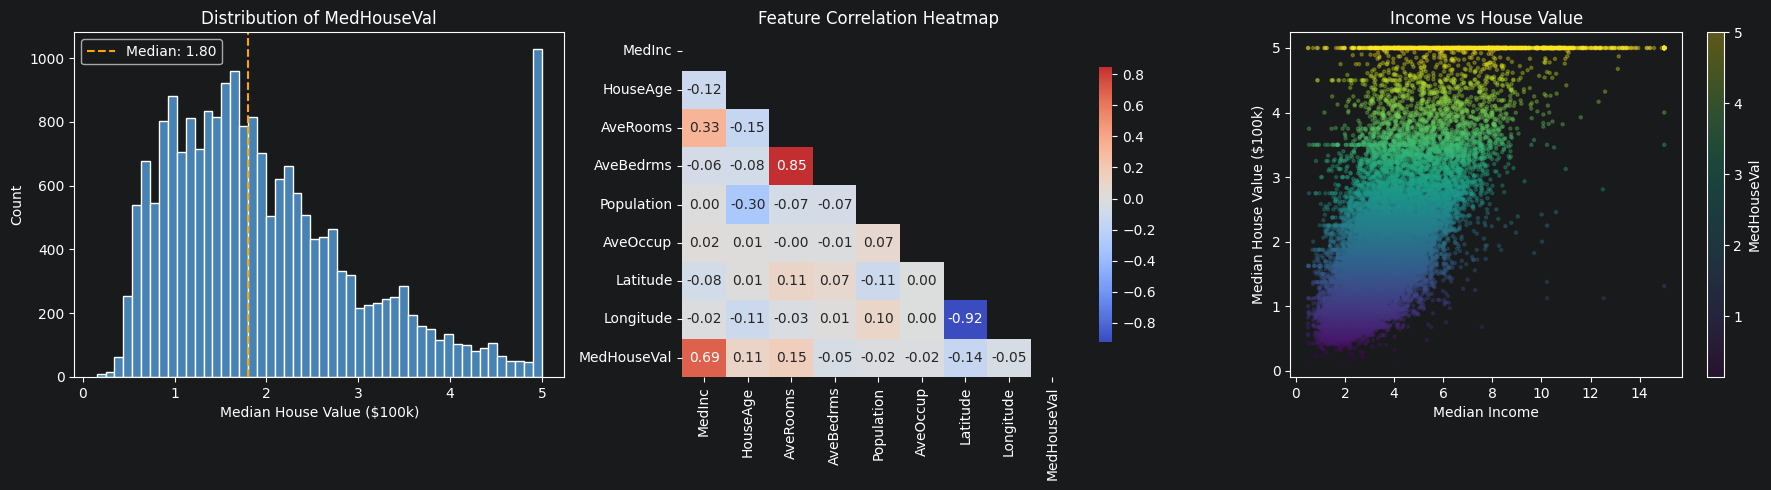

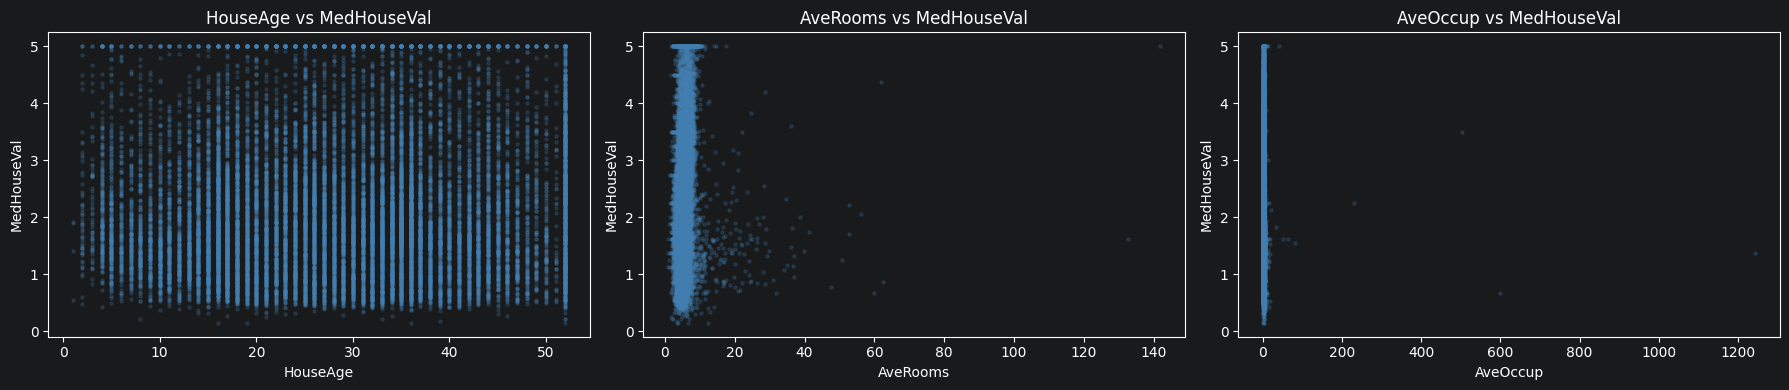

Strongest correlations with MedHouseVal:
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: MedHouseVal, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribution of target variable
axes[0].hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(df['MedHouseVal'].median(), color='orange', linestyle='--', label=f'Median: {df["MedHouseVal"].median():.2f}')
axes[0].set_title('Distribution of MedHouseVal')
axes[0].set_xlabel('Median House Value ($100k)')
axes[0].set_ylabel('Count')
axes[0].legend()

# 2. Correlation heatmap
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Feature Correlation Heatmap')

# 3. Scatter plots of key features vs target
key_features = ['MedInc', 'HouseAge', 'AveRooms', 'AveOccup']
colors = df['MedHouseVal']
sc = axes[2].scatter(df['MedInc'], df['MedHouseVal'], c=colors, cmap='viridis',
                     alpha=0.3, s=5)
axes[2].set_xlabel('Median Income')
axes[2].set_ylabel('Median House Value ($100k)')
axes[2].set_title('Income vs House Value')
plt.colorbar(sc, ax=axes[2], label='MedHouseVal')

plt.tight_layout()
plt.show()

# Additional scatter grid for remaining key features
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 4))
for ax, feat in zip(axes2, ['HouseAge', 'AveRooms', 'AveOccup']):
    ax.scatter(df[feat], df['MedHouseVal'], alpha=0.2, s=5, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('MedHouseVal')
    ax.set_title(f'{feat} vs MedHouseVal')
plt.tight_layout()
plt.show()

print(f"Strongest correlations with MedHouseVal:\n{corr['MedHouseVal'].drop('MedHouseVal').sort_values(ascending=False)}")

## 2. Feature Engineering & Preprocessing

In [5]:
# Engineer new features
df_eng = create_feature_engineering(df)
print(f"Original columns: {df.shape[1]}")
print(f"After engineering: {df_eng.shape[1]}")
print(f"New columns: {set(df_eng.columns) - set(df.columns)}")

Original columns: 9
After engineering: 12
New columns: {'rooms_per_household', 'population_density', 'bedrooms_ratio'}


In [6]:
# Preprocess and split
X_scaled, y, feature_names, scaler = preprocess_features(df_eng)
X_train, X_test, y_train, y_test = split_data(X_scaled, y)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (16512, 11), Test size: (4128, 11)


## 3. Linear Models

In [ ]:
# TODO: Build and evaluate each linear model
# - Linear Regression
# - Ridge Regression (try multiple alphas)
# - Lasso Regression (try multiple alphas)
# - ElasticNet (try multiple alpha and l1_ratio combinations)
# - Polynomial Regression (try degree 2 and 3)

## 4. Tree-Based Models

In [ ]:
# TODO: Build and evaluate tree-based models
# - Decision Tree
# - Random Forest
# - Gradient Boosting
# - XGBoost
# - LightGBM

## 5. Model Comparison

In [ ]:
# TODO: Use compare_models() to create a comparison table
# TODO: Visualize model performance (bar chart of R², RMSE)

## 6. Regression Diagnostics

### Multicollinearity (VIF Analysis)

In [ ]:
# TODO: Compute VIF for each feature using statsmodels
# from statsmodels.stats.outliers_influence import variance_inflation_factor
# Identify features with VIF > 10 (high multicollinearity)

### Heteroskedasticity Testing

In [ ]:
# TODO: Check for heteroskedasticity
# - Plot residuals vs fitted values
# - Breusch-Pagan test (statsmodels)
# - Apply log transformation to target if needed

## 7. Cross-Validation

In [ ]:
# TODO: Cross-validate the top 3 models
# Use cross_validate_model() and compare results

## Summary

TODO: Write a summary of your findings:
- Which model performed best and why?
- What did VIF analysis reveal?
- Were there heteroskedasticity issues?
- Which features are most important?